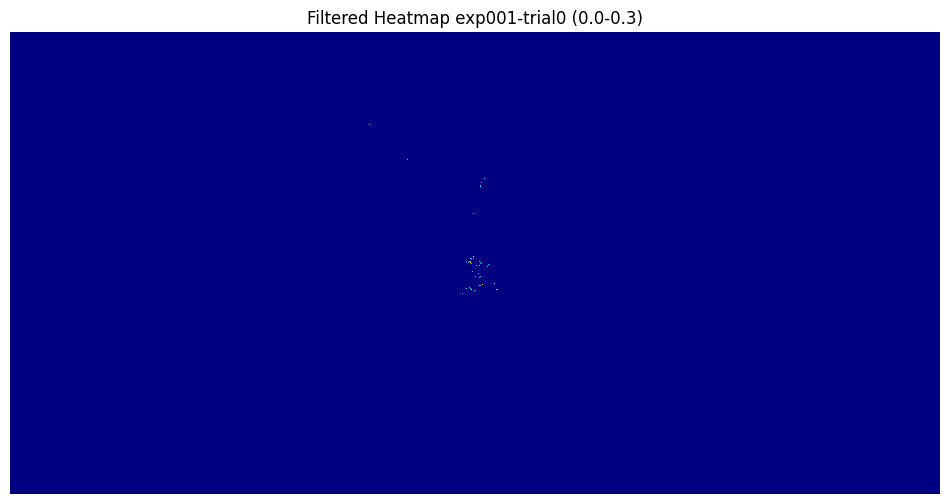

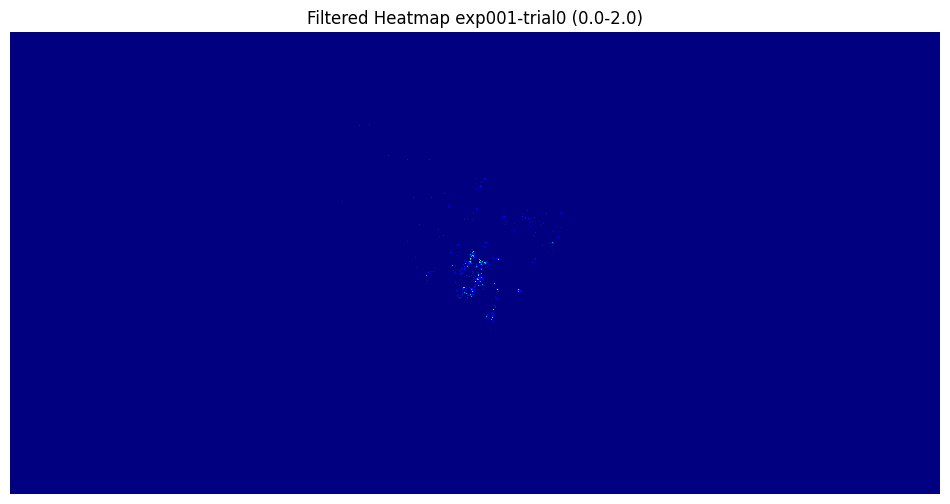

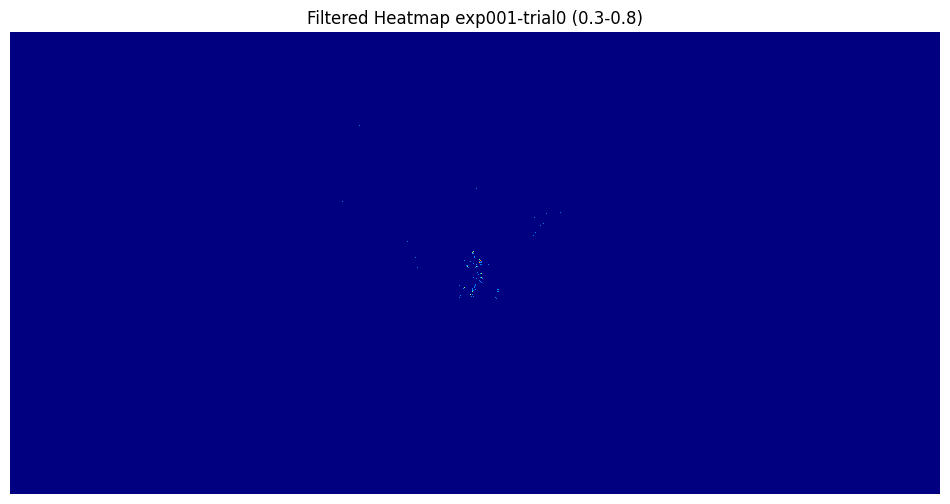

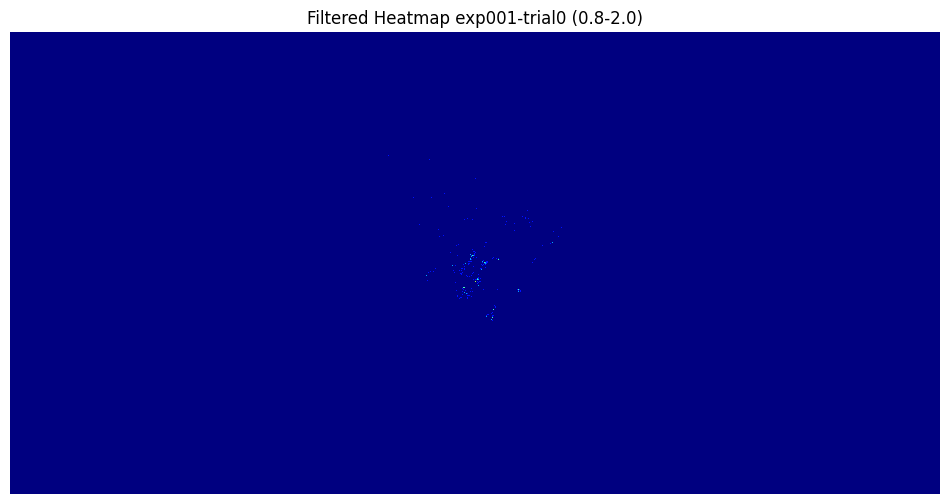

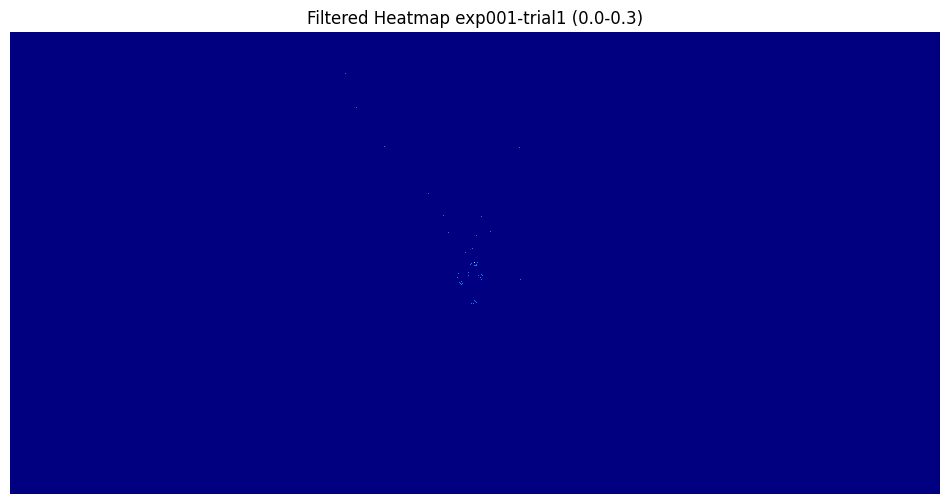

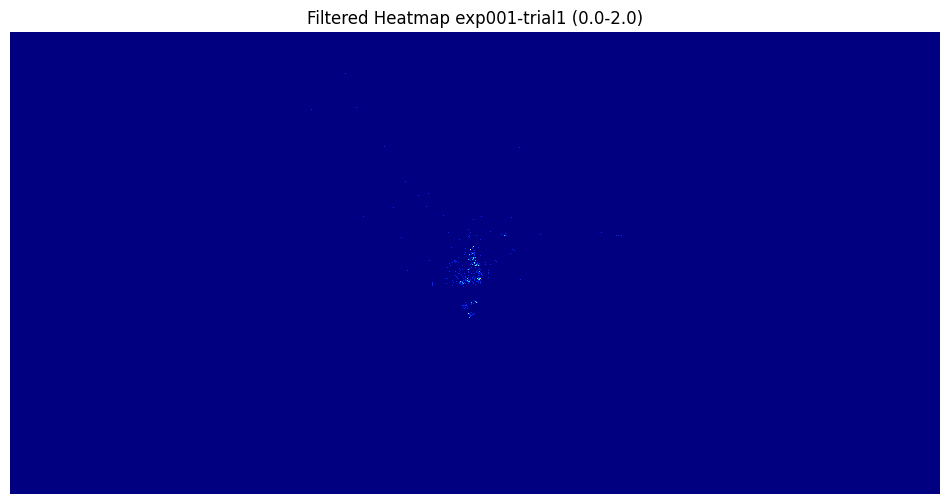

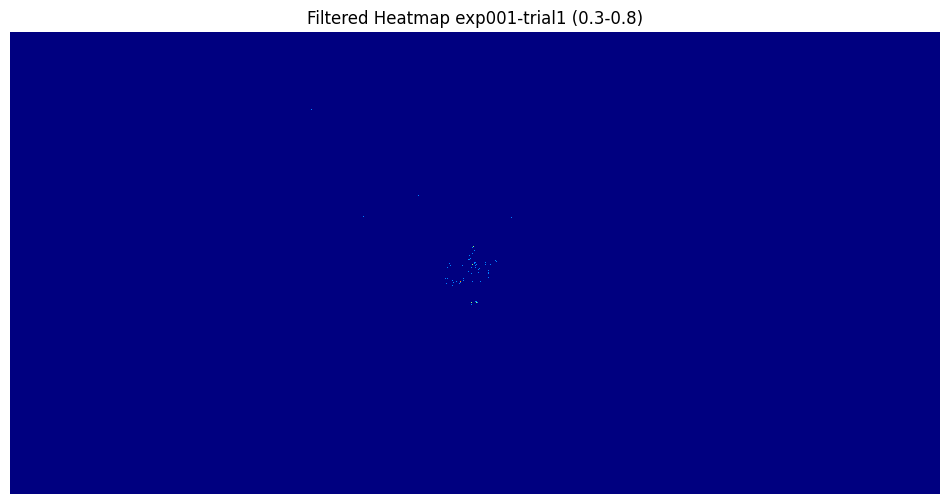

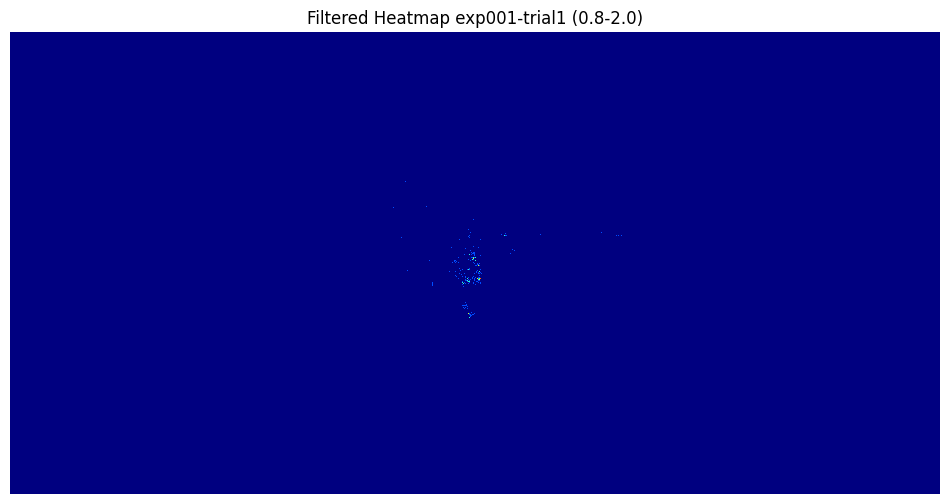

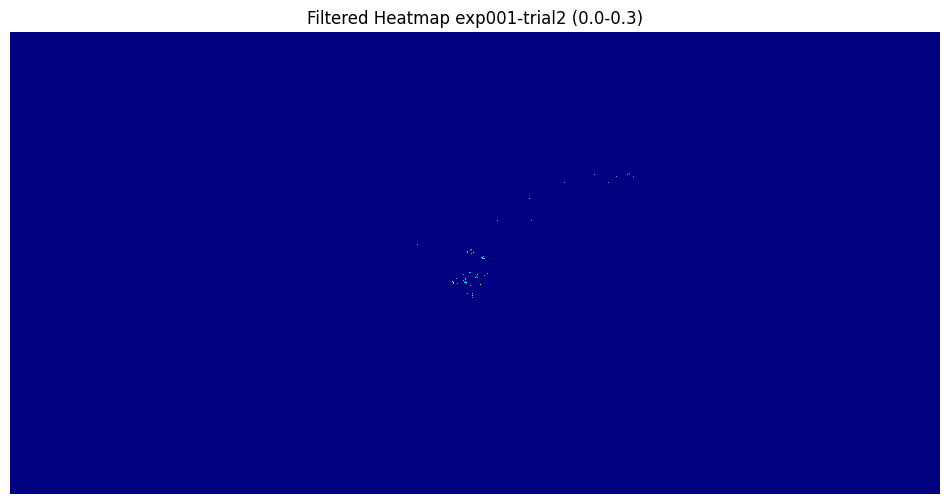

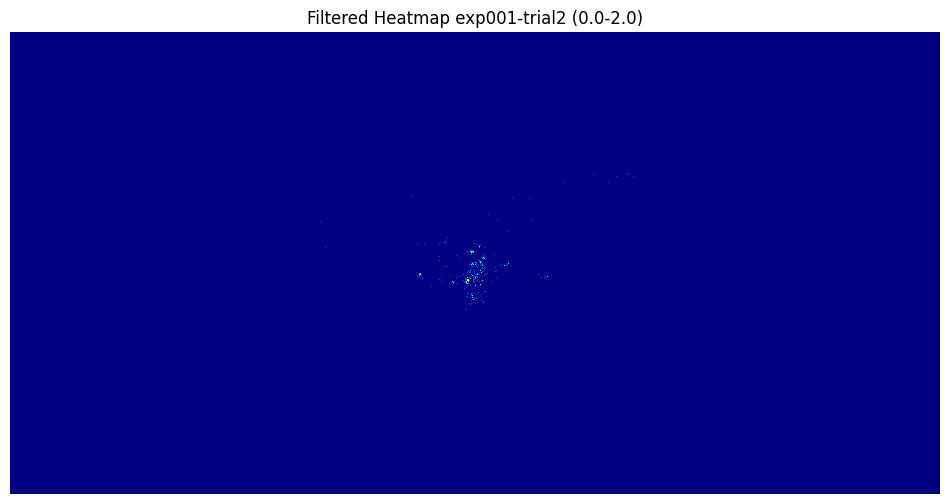

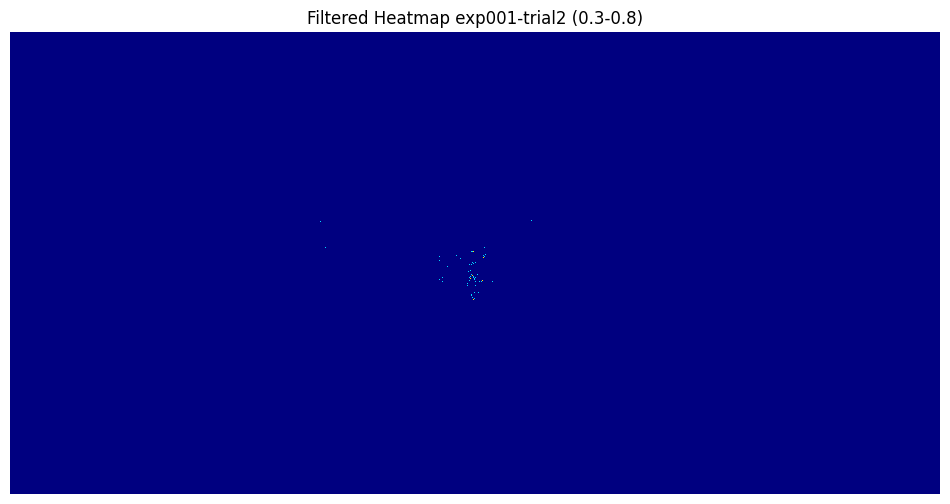

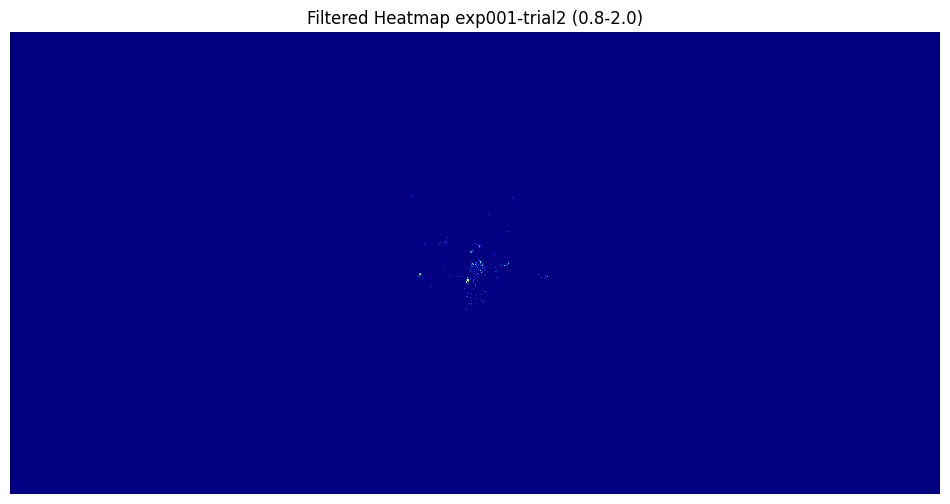

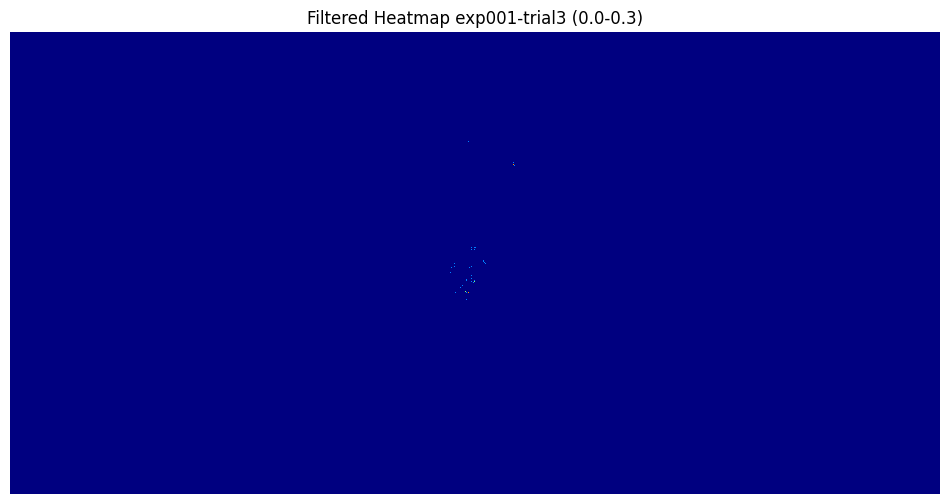

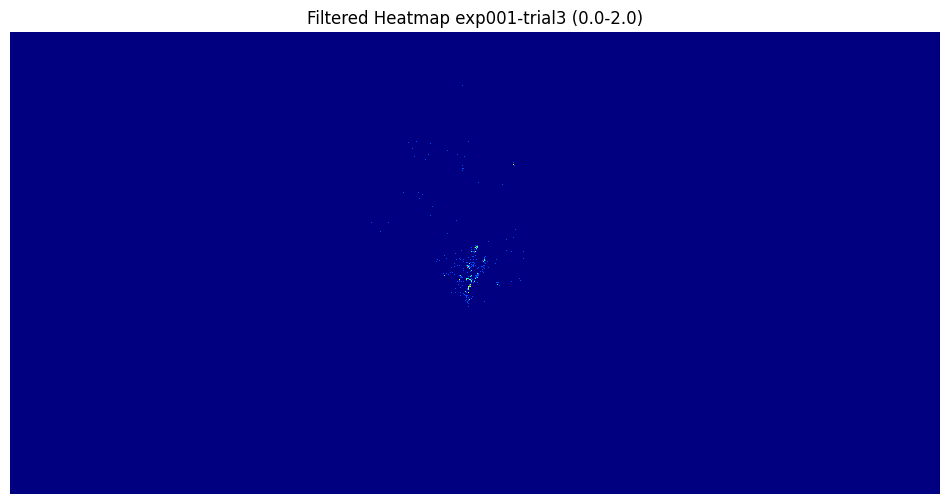

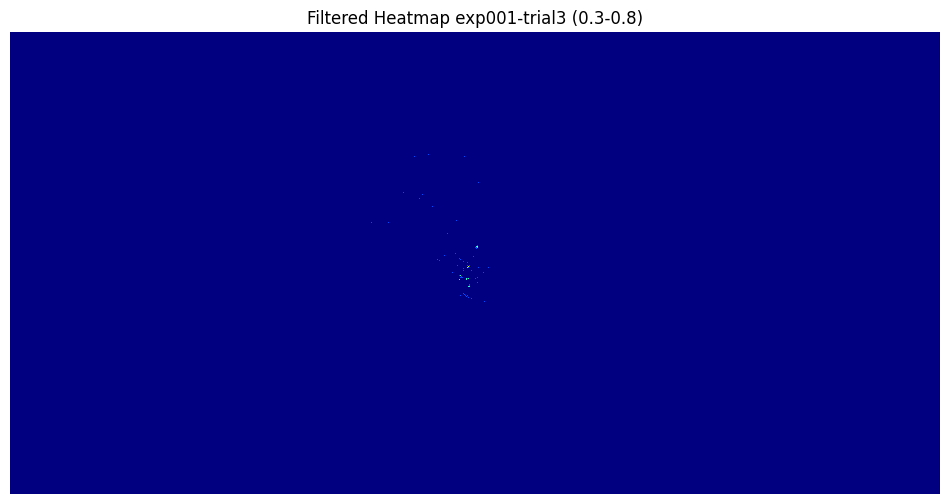

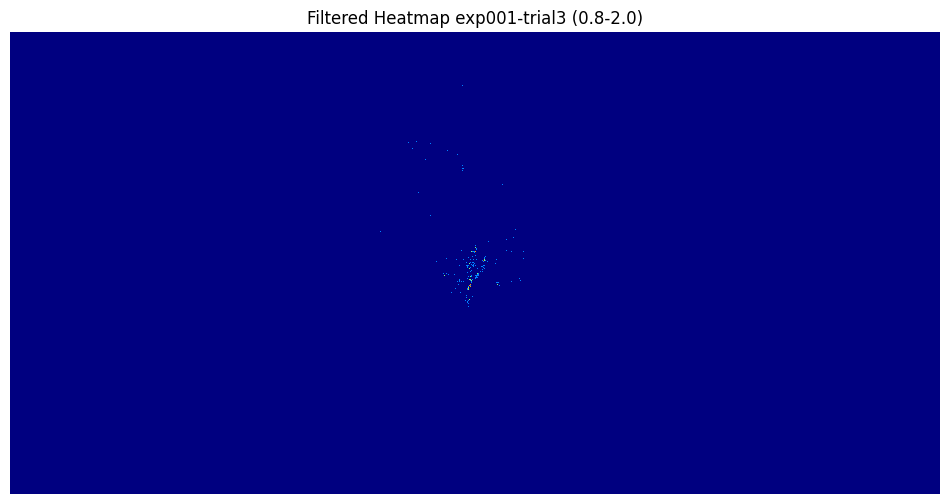

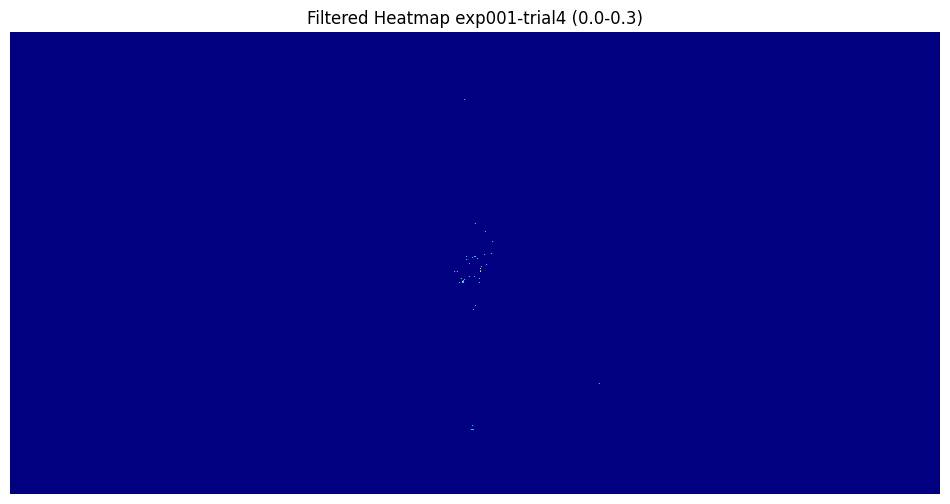

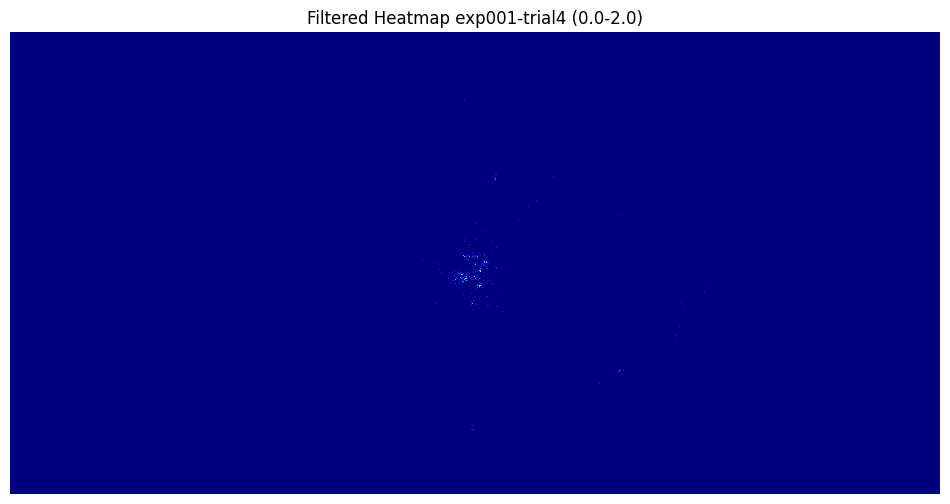

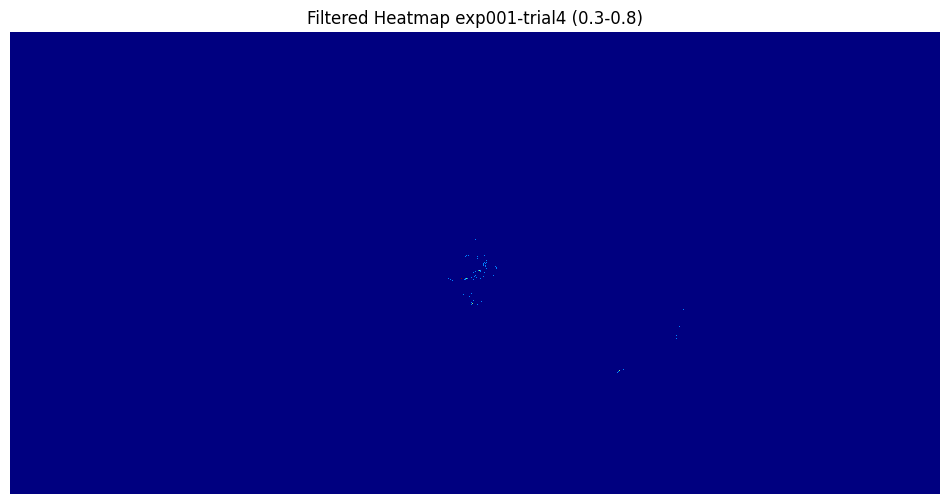

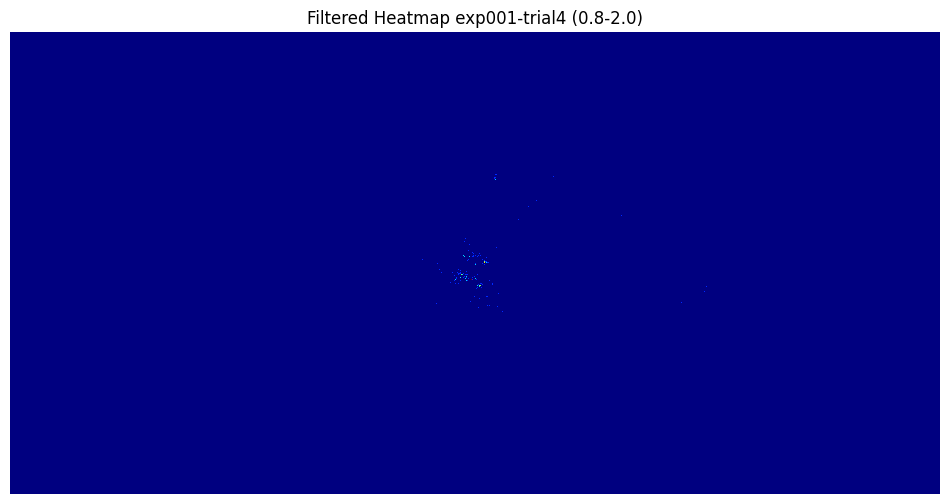

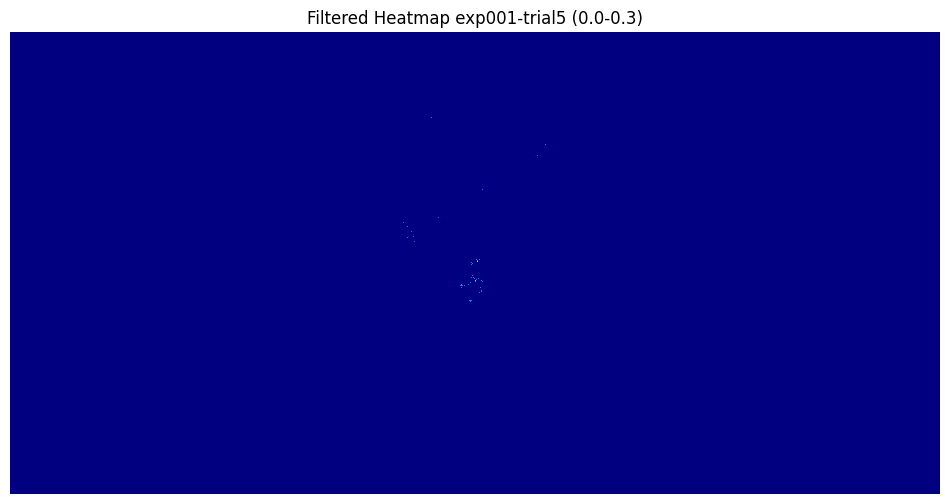

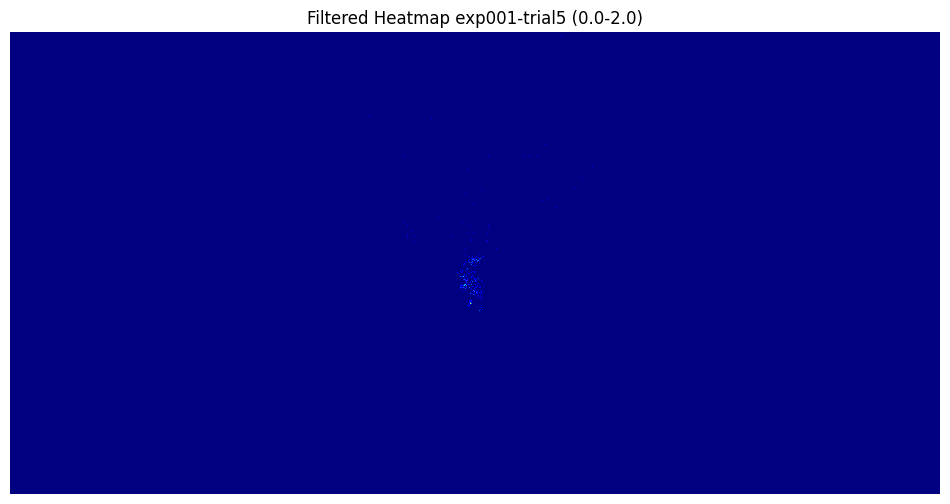

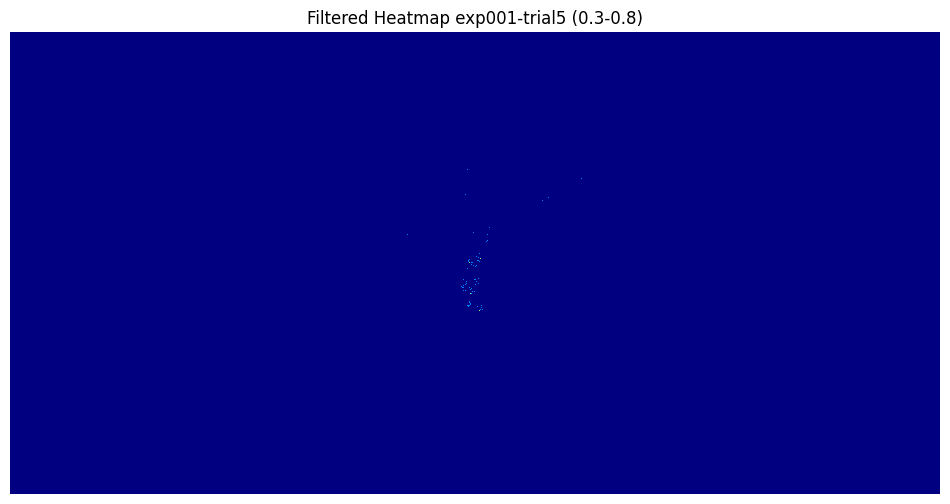

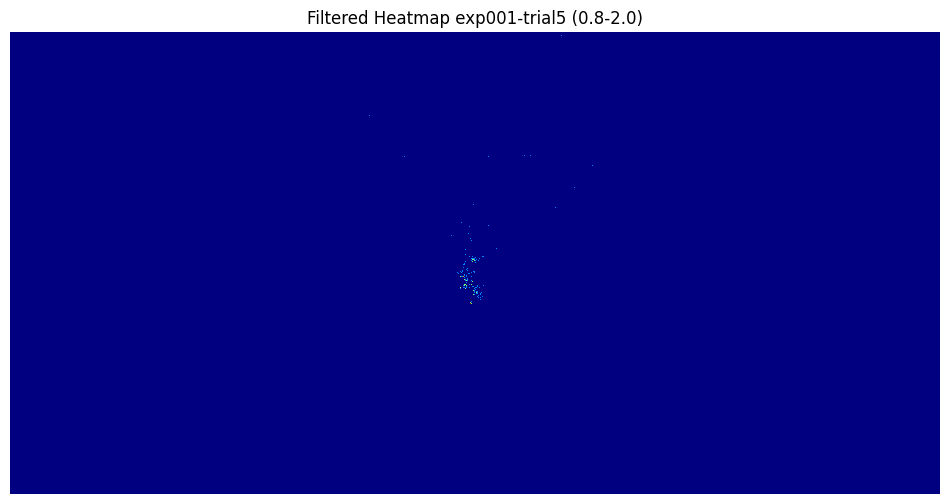

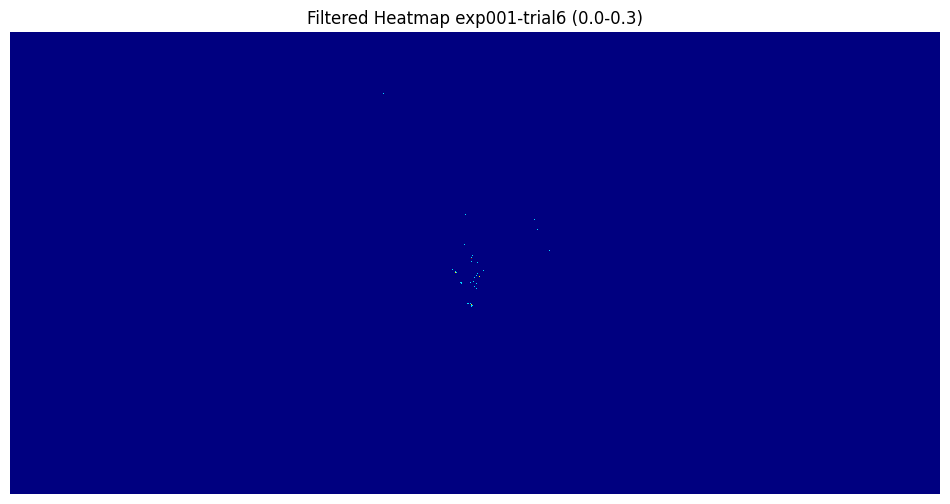

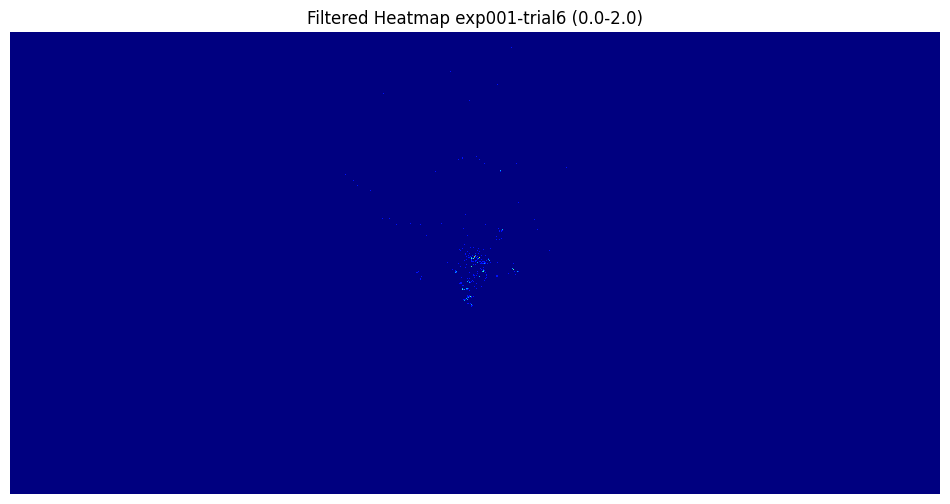

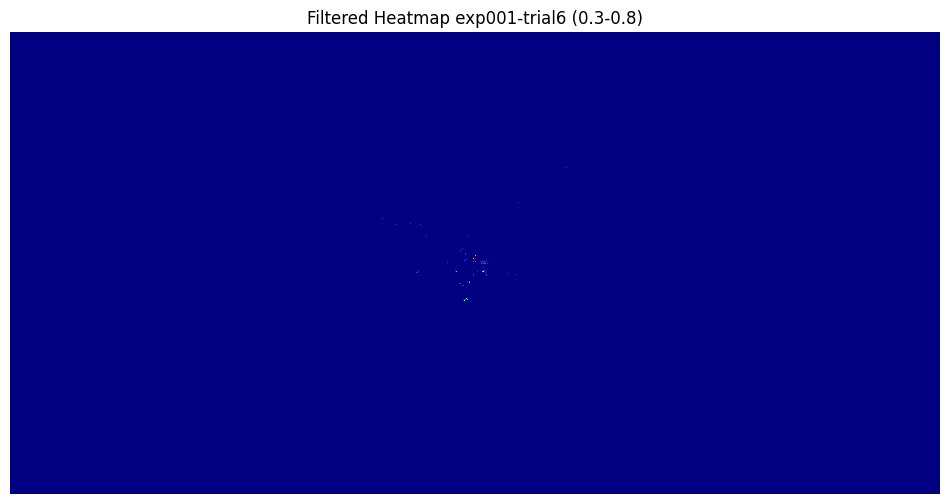

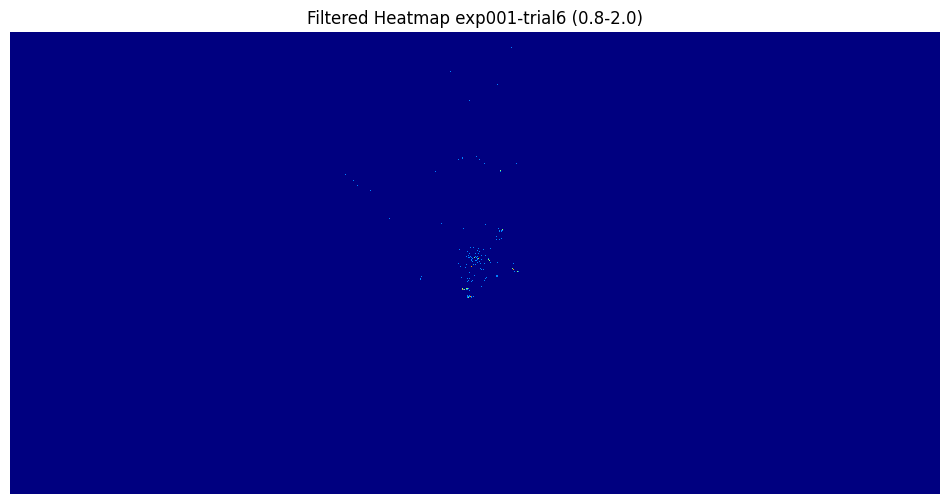

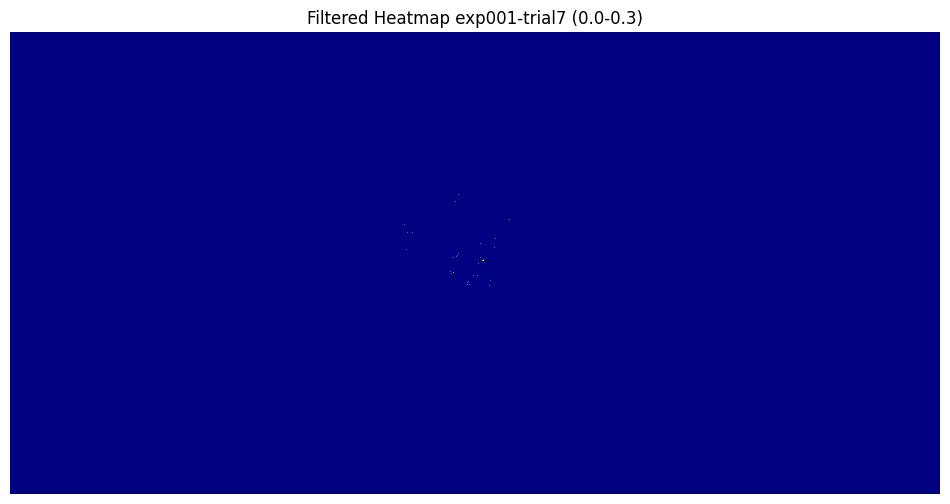

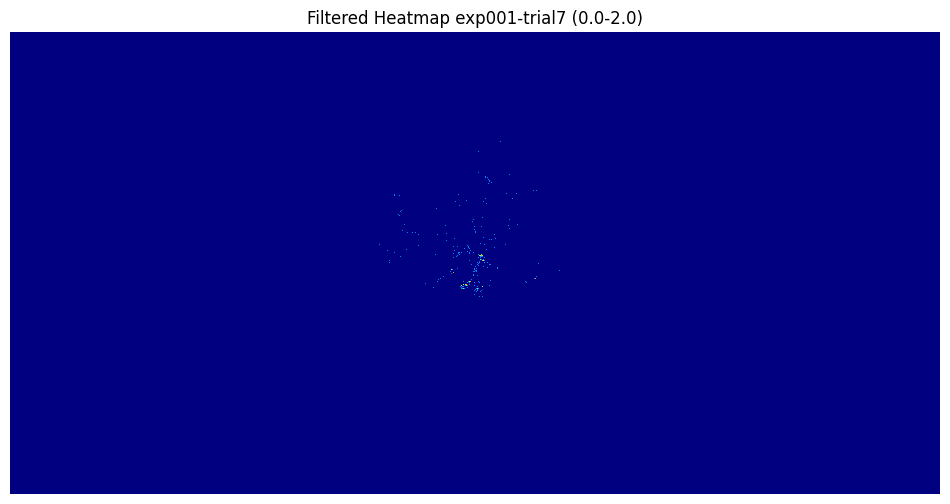

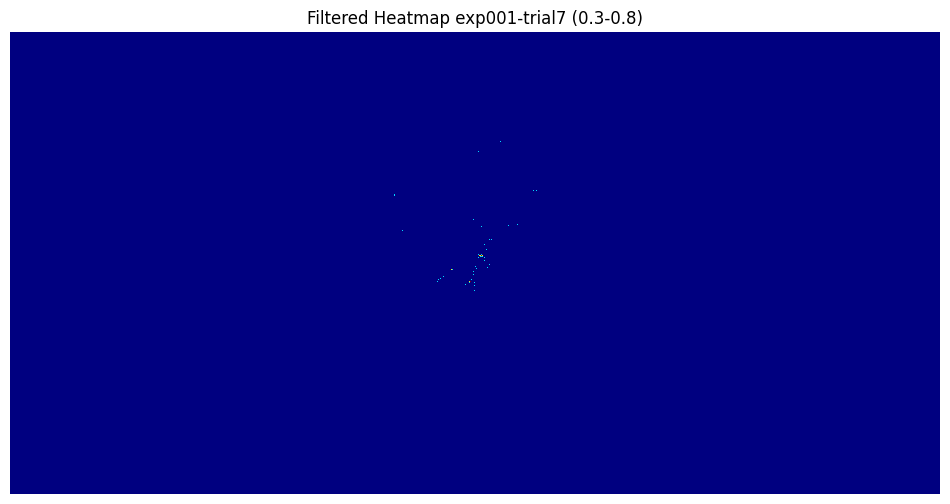

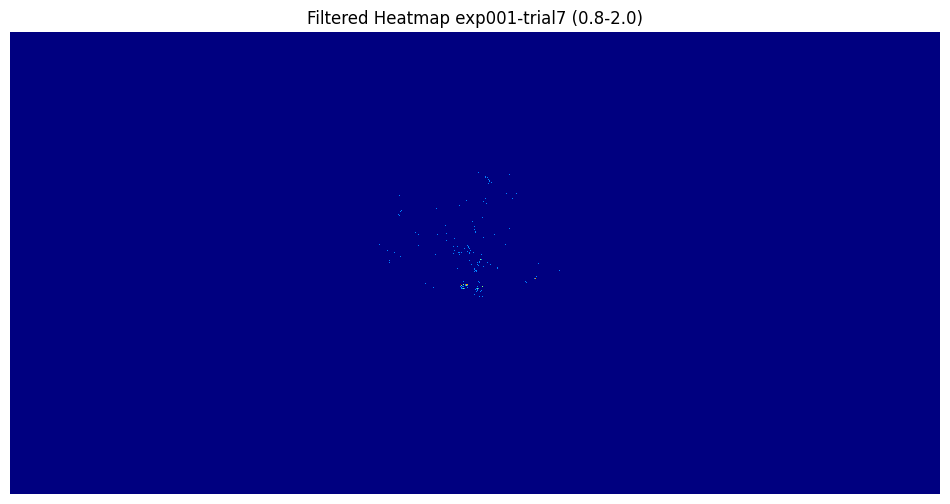

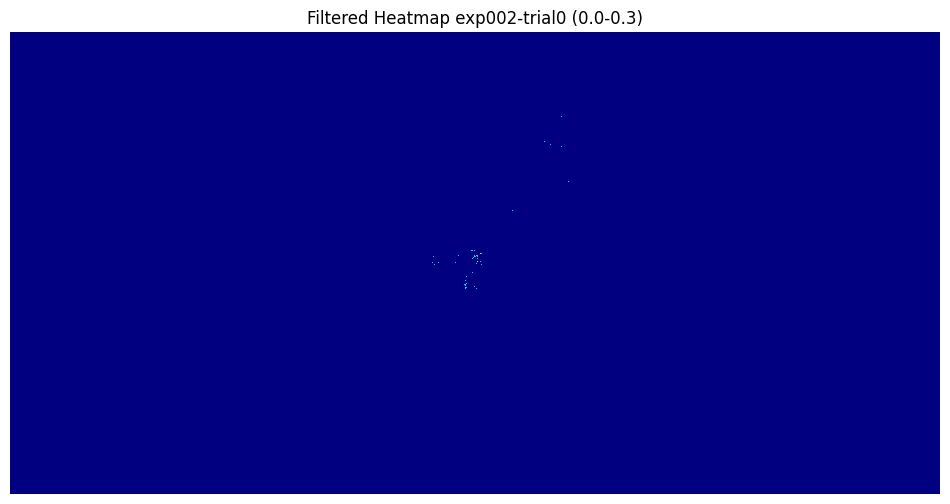

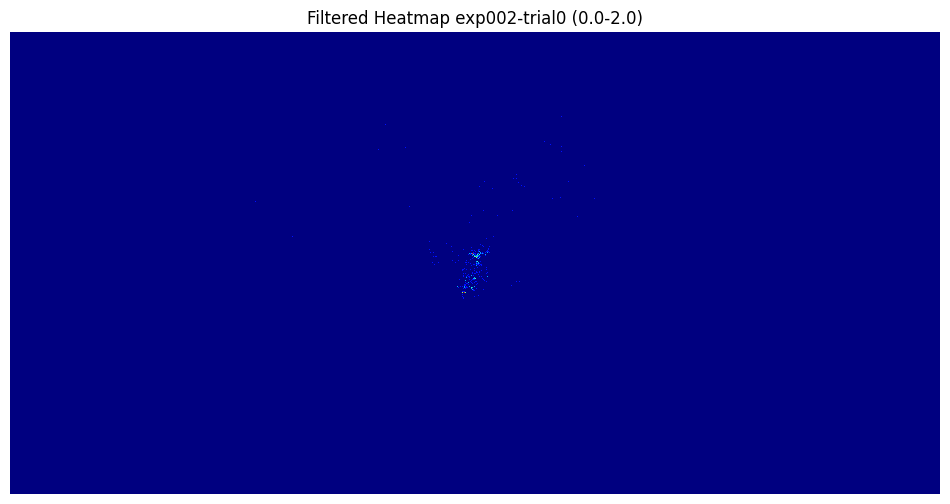

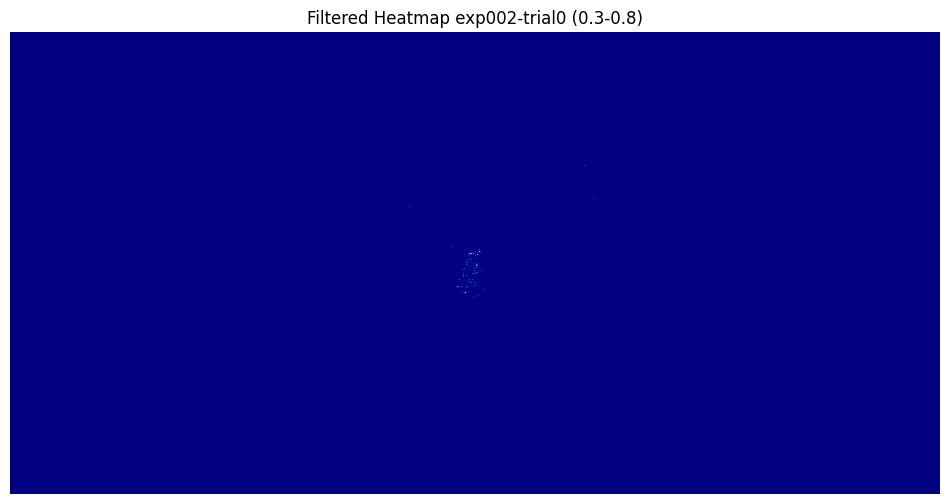

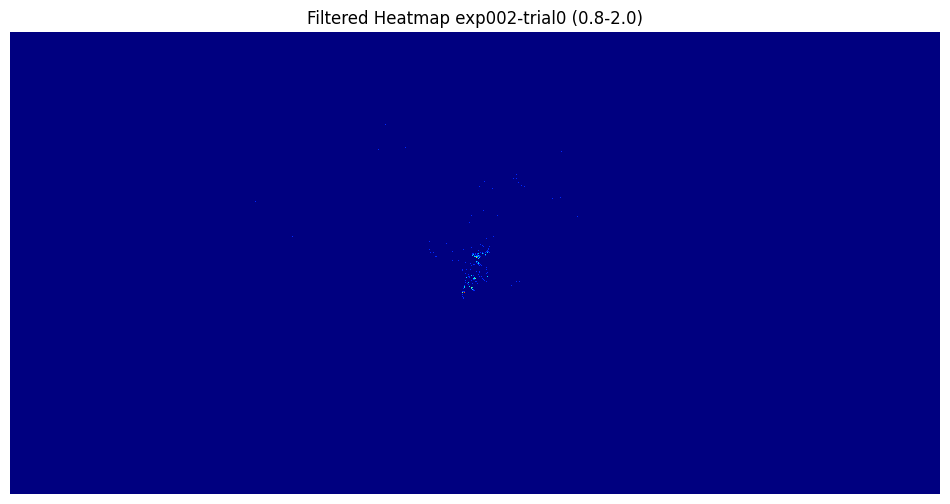

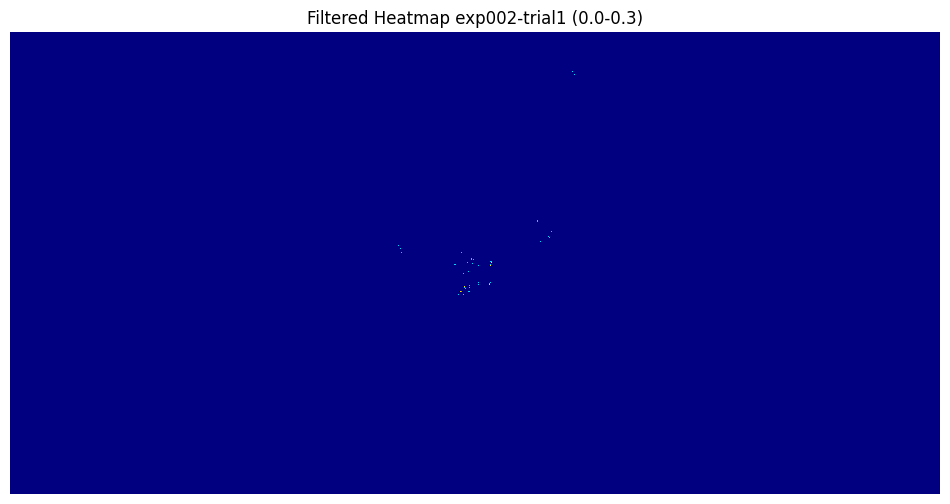

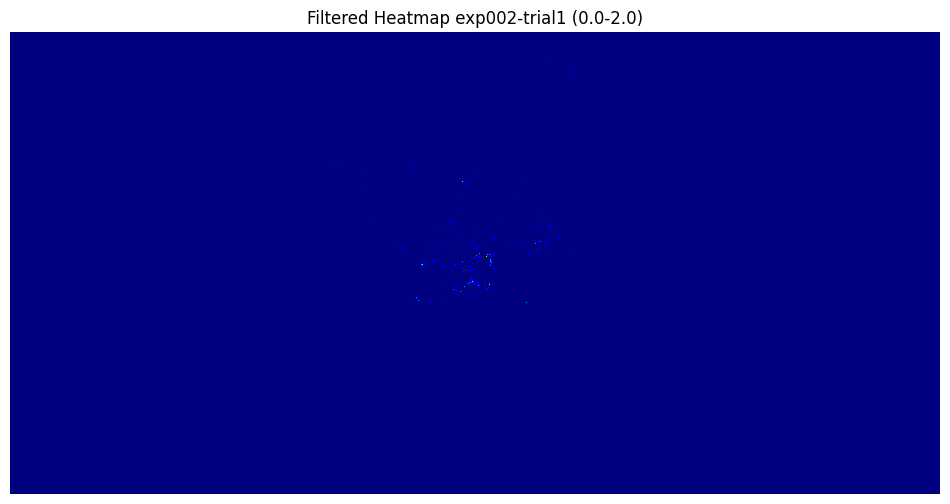

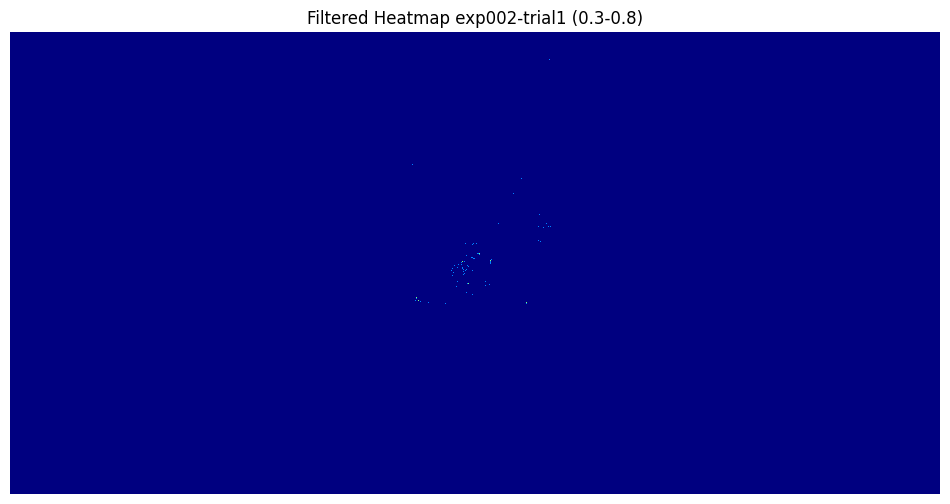

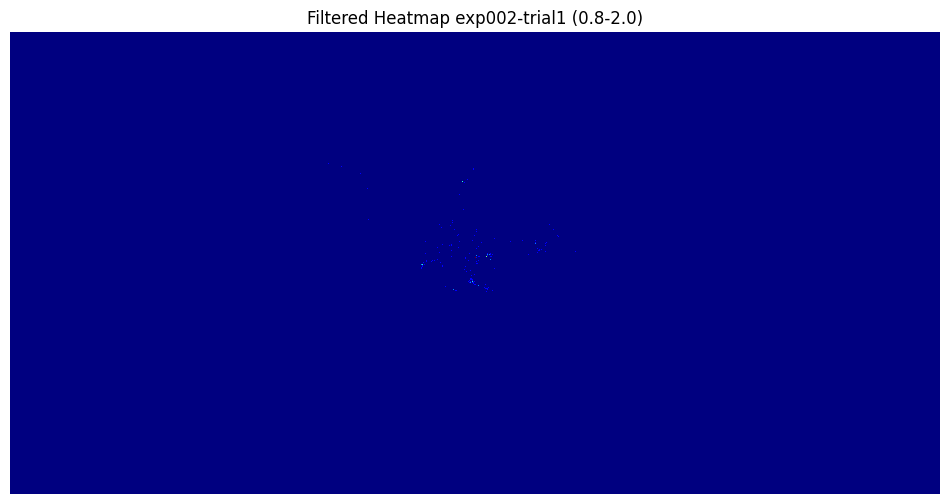

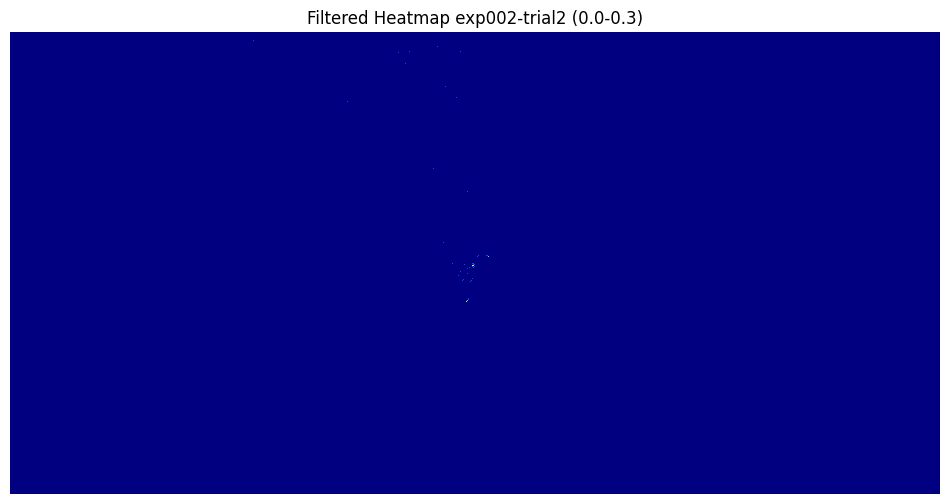

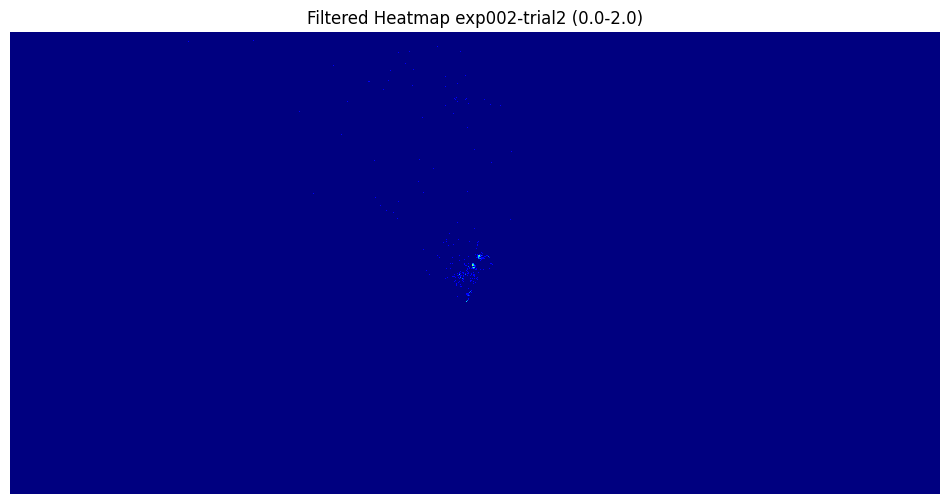

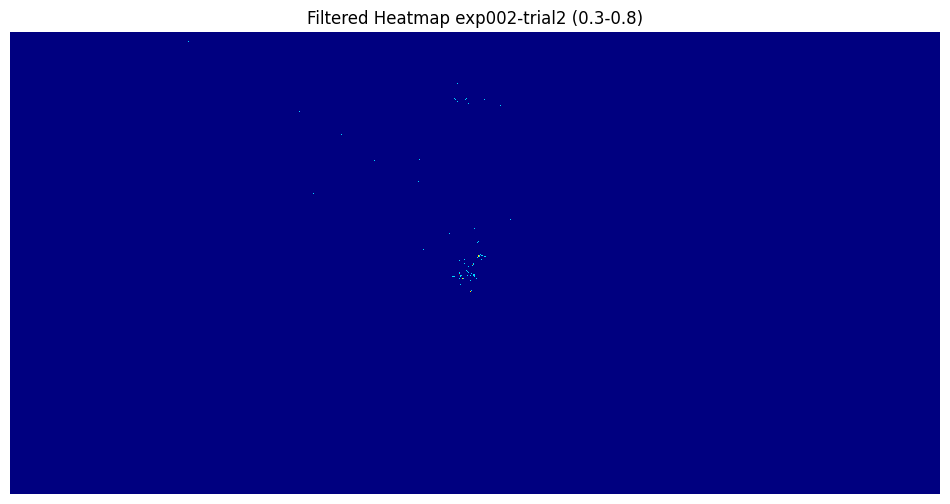

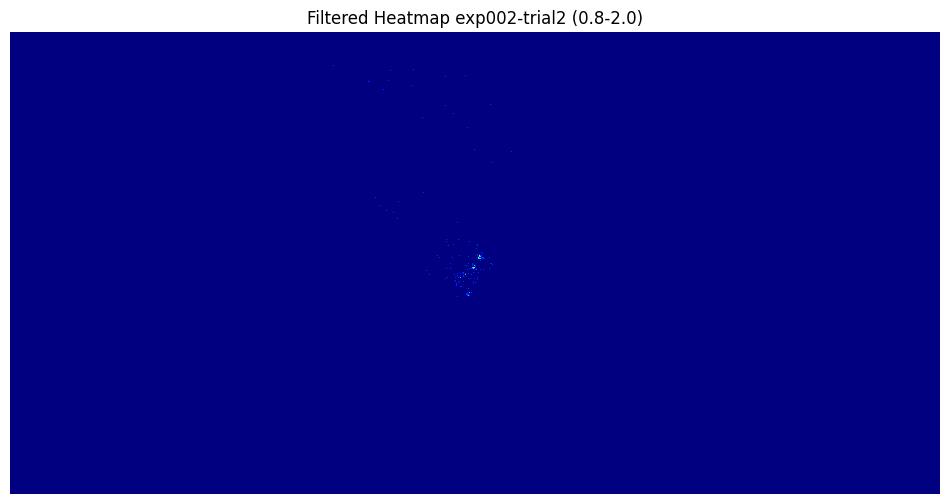

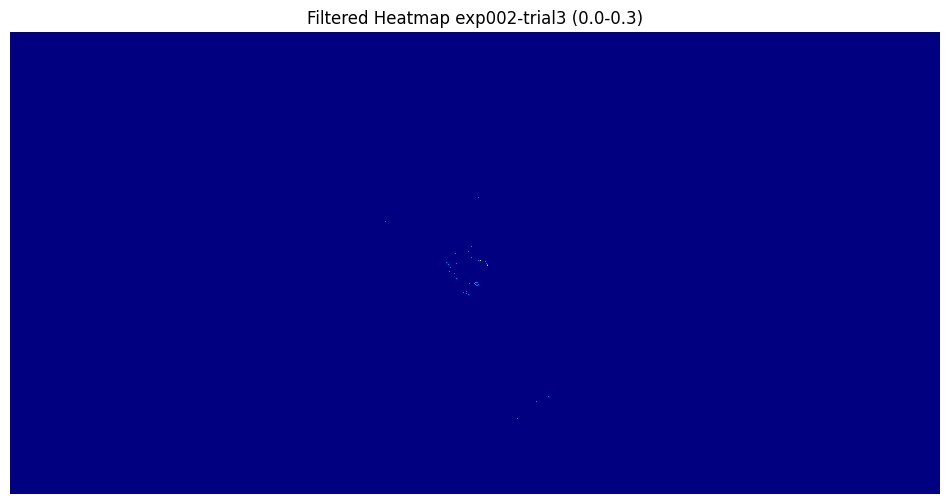

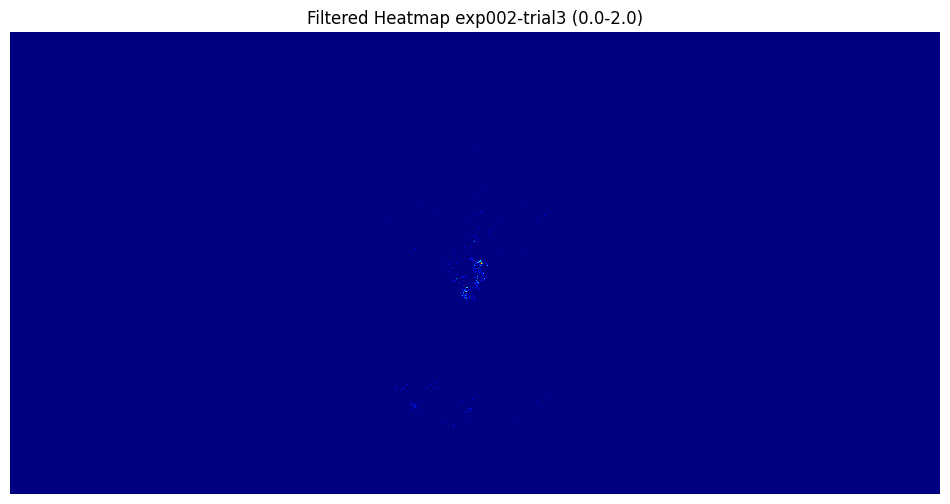

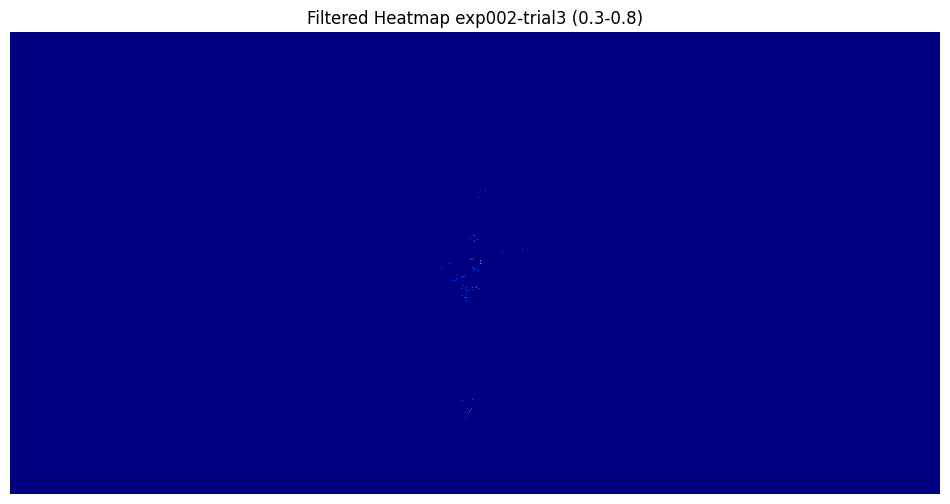

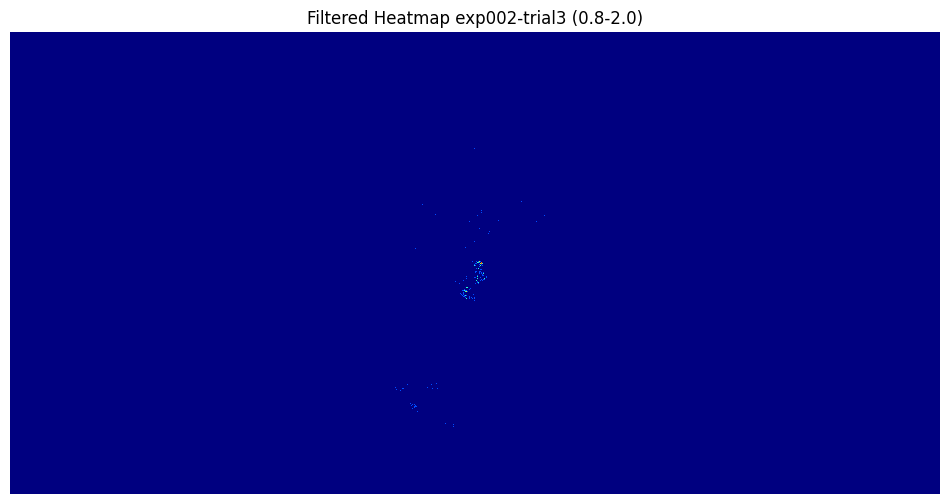

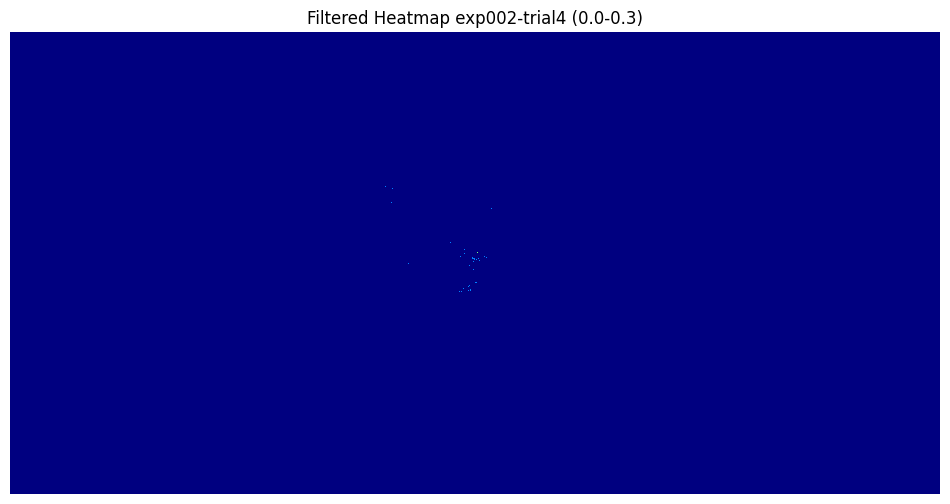

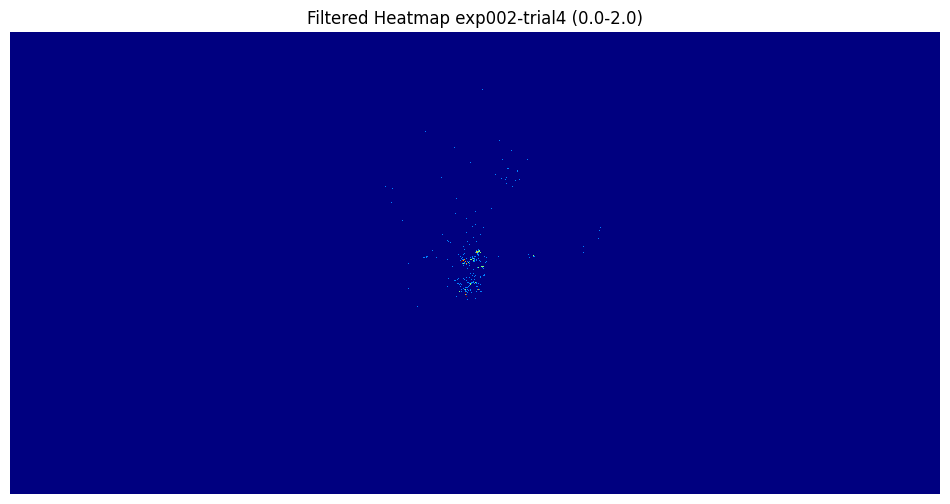

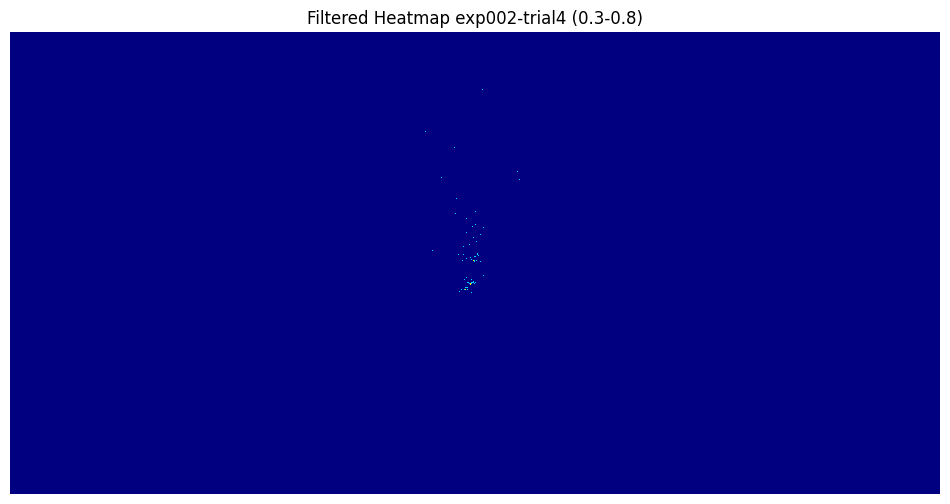

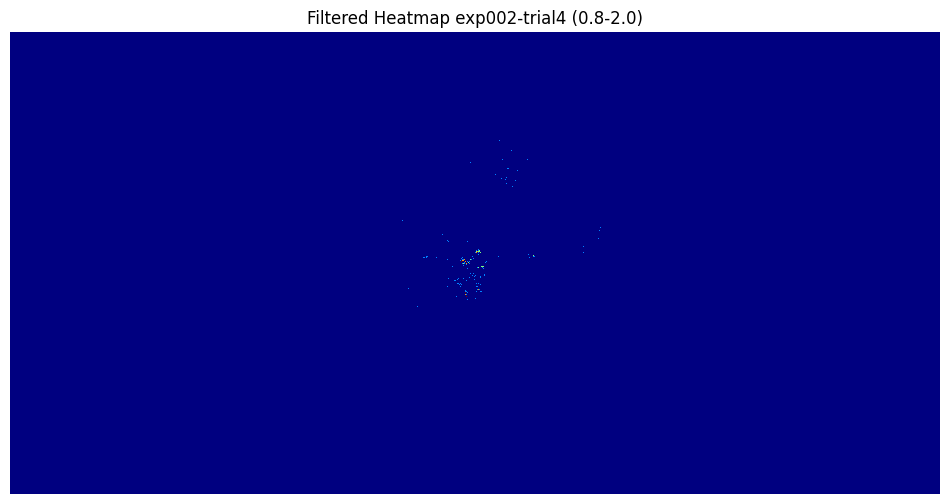

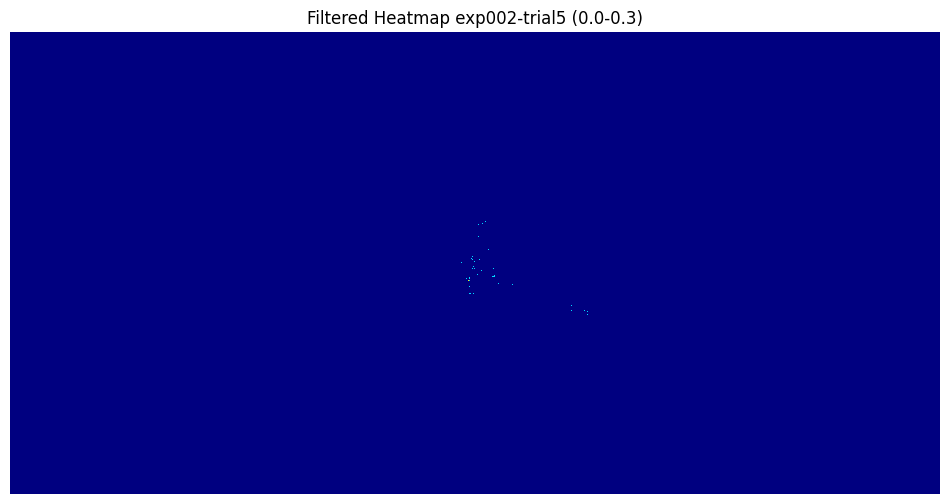

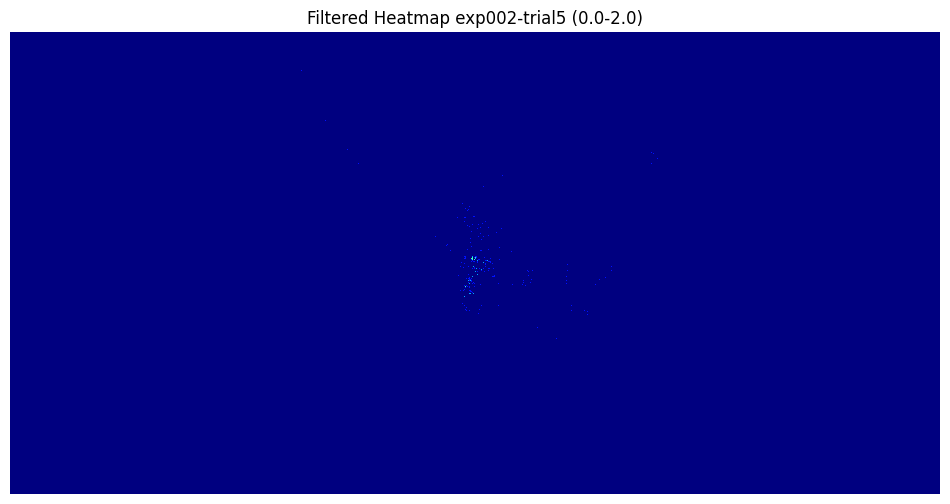

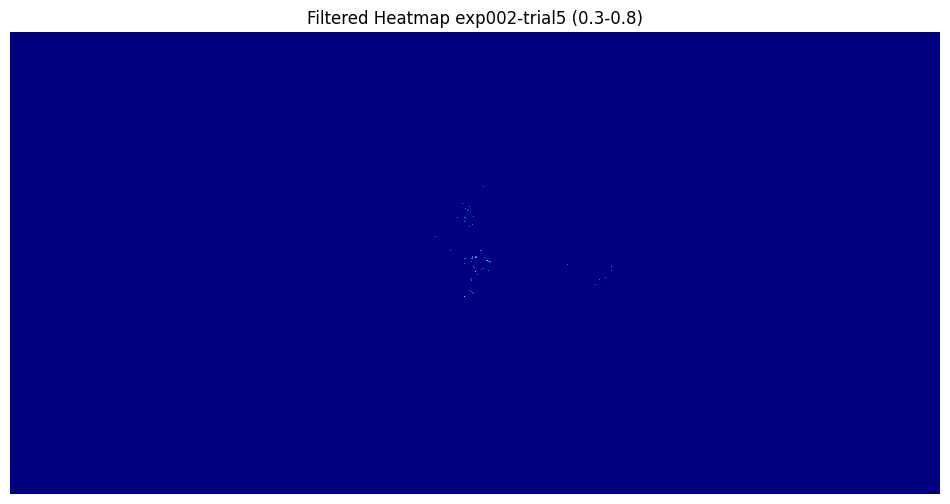

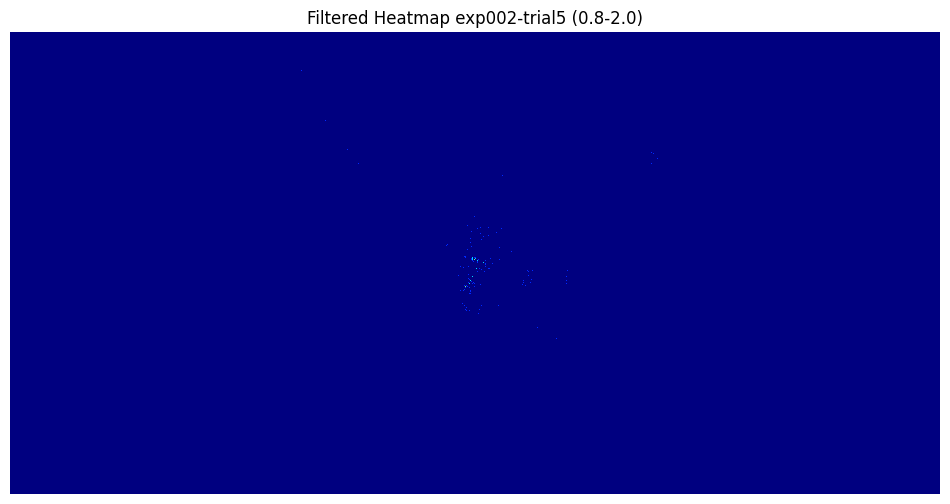

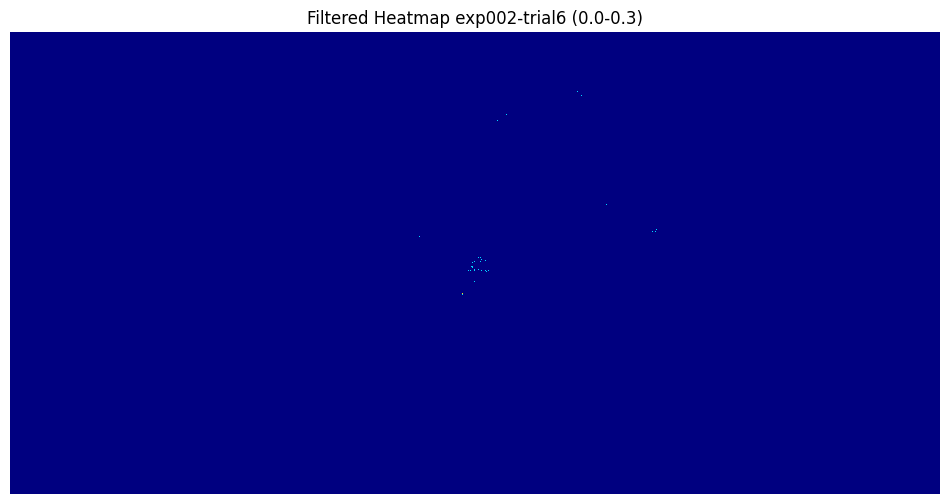

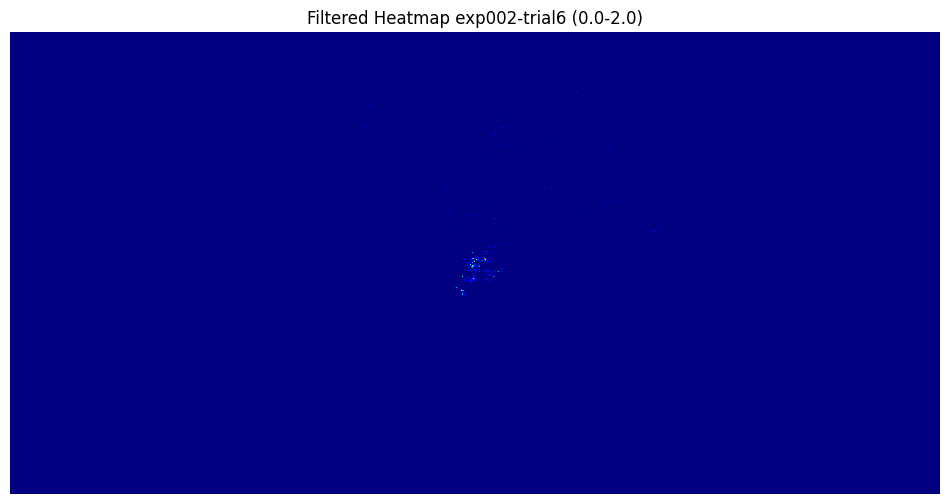

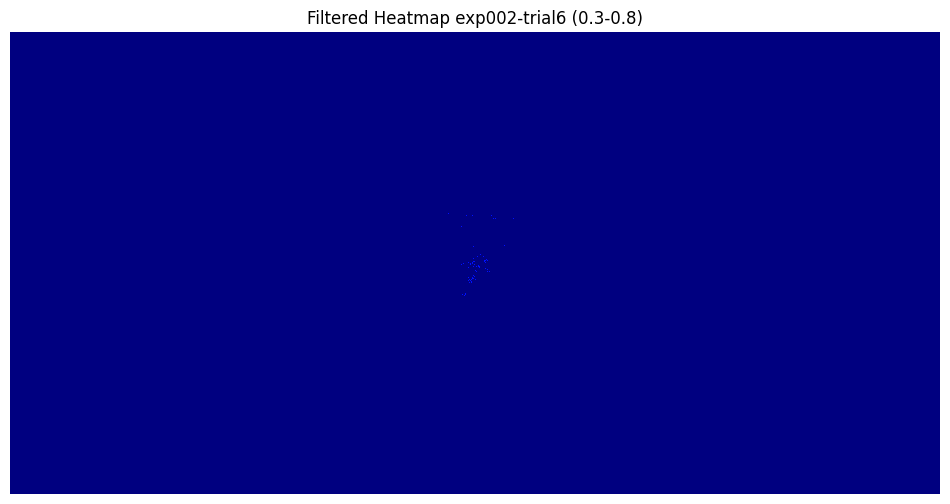

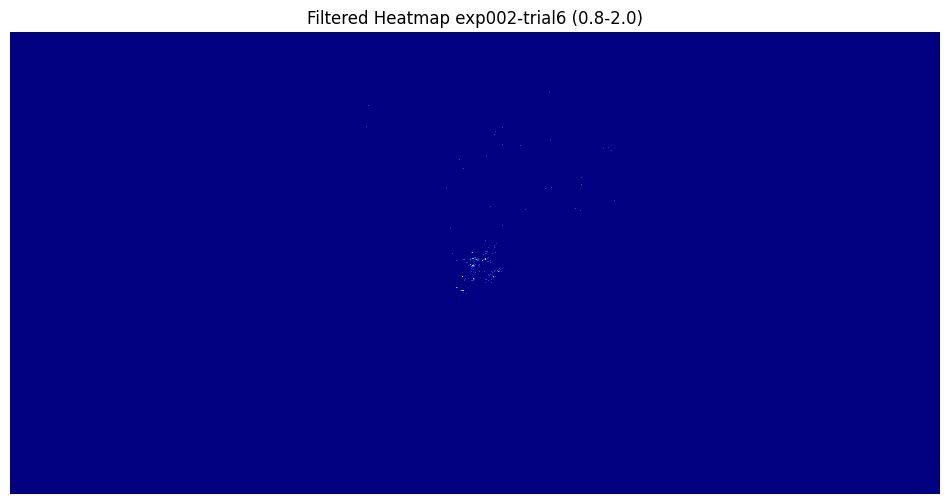

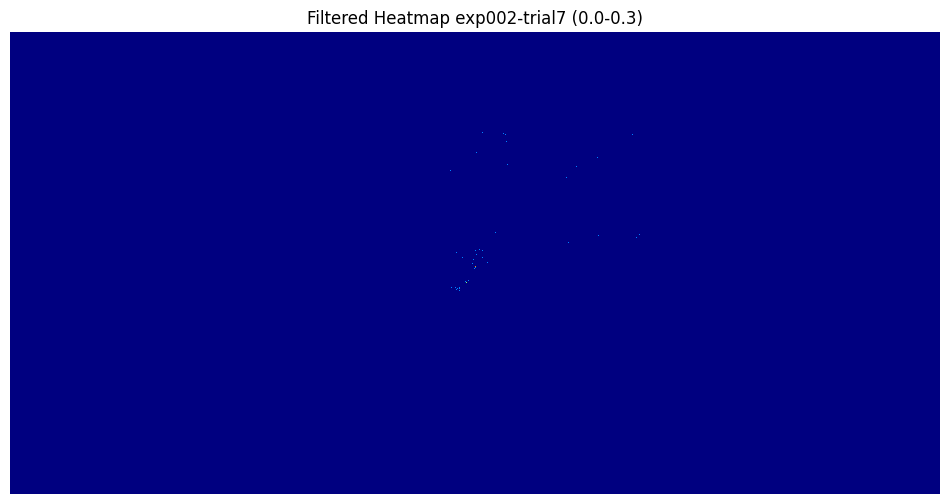

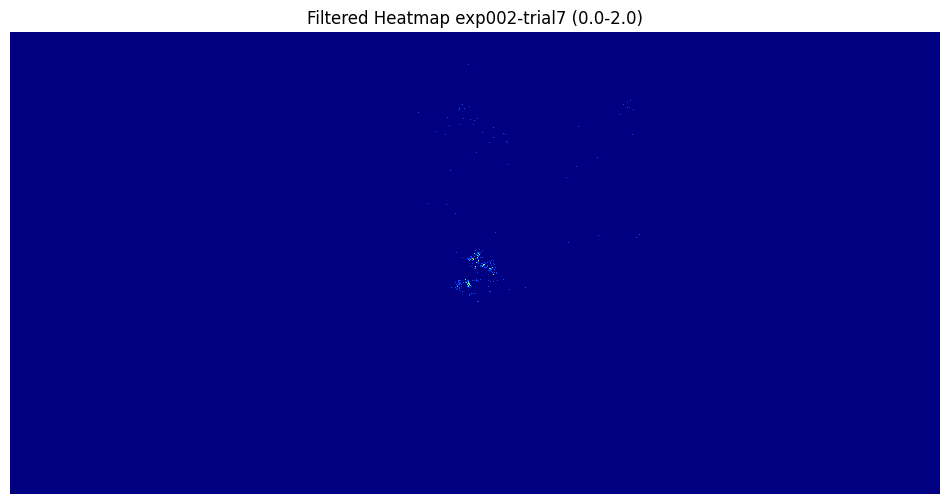

KeyboardInterrupt: 

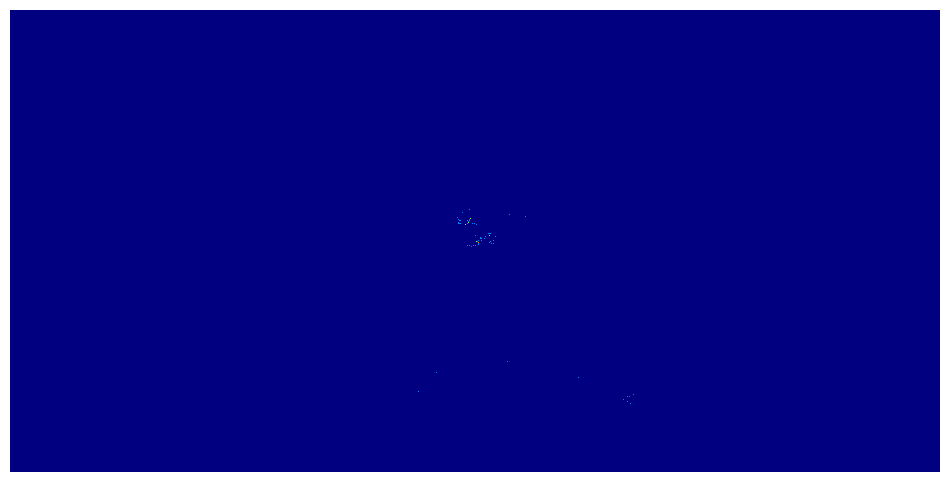

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === 入出力設定 ===
input_dirs = {
    "filtered": "../exported_csv/filtered_IVT_split",
    "fixation": "../exported_csv/fixation_IVT_split"
}
output_dirs = {
    "filtered": "../exported_csv/heatmap_filtered",
    "fixation": "../exported_csv/heatmap_fixation"
}

# 画面サイズ
screen_w, screen_h = 1920, 1080
bin_size = 30  # 必要に応じて変更

# 出力先作成
for out_dir in output_dirs.values():
    os.makedirs(out_dir, exist_ok=True)

# === 各データタイプで処理 ===
for data_type in ["filtered", "fixation"]:
    input_dir = input_dirs[data_type]
    output_dir = output_dirs[data_type]

    # experiment-trial-intervalごとにデータをまとめる
    heatmap_data = {}  # {(exp_id, trial, interval): [(x, y), ...]}

    for fname in os.listdir(input_dir):
        if not fname.endswith(".csv"):
            continue

        # 例: filtered_df_001-002-3_0.3-0.8.csv
        try:
            parts = fname.split("_")
            exp_trial = parts[2]  # 001-002-3
            interval = parts[3].replace(".csv", "")
            exp_id = int(exp_trial.split("-")[1])
            trial = int(exp_trial.split("-")[2])
        except:
            continue

        df = pd.read_csv(os.path.join(input_dir, fname))
        if df.empty:
            continue

        # データの抽出（filtered or fixation）
        if data_type == "filtered":
            if "x_px" not in df.columns or "y_px" not in df.columns:
                continue
            coords = list(zip(df["x_px"], df["y_px"]))
        else:
            if "x_mean_px" not in df.columns or "y_mean_px" not in df.columns:
                continue
            coords = list(zip(df["x_mean_px"], df["y_mean_px"]))

        key = (exp_id, trial, interval)
        heatmap_data.setdefault(key, []).extend(coords)

    # === 描画 ===
    for (exp_id, trial, interval), coords in heatmap_data.items():
        if not coords:
            continue

        # 座標をヒートマップに変換
        heatmap = np.zeros((screen_h, screen_w))
        for x, y in coords:
            if np.isnan(x) or np.isnan(y):  # NaNチェック
                continue
            xi = int(min(max(x, 0), screen_w - 1))
            yi = int(min(max(y, 0), screen_h - 1))
            heatmap[yi, xi] += 1


        # 描画
        plt.figure(figsize=(12, 6))
        sns.heatmap(
            heatmap,
            cmap="jet",
            cbar=False,
            xticklabels=False,
            yticklabels=False
        )
        plt.gca().invert_yaxis()
        plt.title(f"{data_type.capitalize()} Heatmap exp{exp_id:03}-trial{trial} ({interval})")
        plt.show()

        # out_path = os.path.join(output_dir, f"heatmap_{exp_id:03}-{trial}_{interval}.png")
        # plt.savefig(out_path, dpi=300, bbox_inches="tight")
        # plt.close()

    print(f"✅ {data_type} のヒートマップ出力が完了しました。")
